Enlace al dataset: https://www.kaggle.com/datasets/harturo123/online-adds-of-used-cars?select=data.csv

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import joblib
import os
import sys


In [63]:
df = pd.read_csv('../datasets/data.csv', sep=';')

In [64]:
df.head()

,ID,make,model,version,months_old,power,sale_type,num_owners,gear_type,fuel_type,kms,price
0,97860,Porsche,911,Carrera 4 S Coup�,240.0,210.0,classic,3.0,manual,gasoline,202000.0,999999
1,27821,Ford,Mustang,Gt500 Cabrio Vendido,54.0,487.0,used,1.0,manual,gasoline,30000.0,685000
2,97801,Porsche,911,3.3 Turbo Targa (Precio A Consultar),358.0,220.0,used,NaN,manual,gasoline,56300.0,555555
3,98251,Porsche,911,R Unidad 343 De 991-Iva Deducible,14.0,368.0,used,1.0,manual,gasoline,2800.0,470000
4,98250,Porsche,911,Gt2 Rs,3.0,515.0,used,NaN,NaN,gasoline,10.0,450000


In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 93991 entries, 0 to 93990
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          93991 non-null  int64  
 1   make        93991 non-null  str    
 2   model       93991 non-null  str    
 3   version     93991 non-null  str    
 4   months_old  93717 non-null  float64
 5   power       93504 non-null  float64
 6   sale_type   93979 non-null  str    
 7   num_owners  22660 non-null  float64
 8   gear_type   92710 non-null  str    
 9   fuel_type   93926 non-null  str    
 10  kms         93127 non-null  float64
 11  price       93991 non-null  int64  
dtypes: float64(4), int64(2), str(6)
memory usage: 8.6 MB


In [66]:
df.describe()

,ID,months_old,power,num_owners,kms,price
count,93991.00000,93717.000000,93504.000000,22660.000000,93127.000000,93991.000000
mean,55100.87935,63.094775,99.729477,1.055119,82702.565250,16587.291379
std,33119.32602,56.837686,42.698809,0.277124,75186.697789,15563.712383
min,25.00000,1.000000,0.000000,1.000000,0.000000,200.000000
25%,25452.50000,16.000000,77.000000,1.000000,18300.000000,8500.000000
50%,53896.00000,46.000000,88.000000,1.000000,66000.000000,13490.000000
75%,83573.50000,96.000000,110.000000,1.000000,129000.000000,19999.000000
max,113143.00000,374.000000,809.000000,11.000000,497000.000000,999999.000000


In [67]:
df.isnull().sum()

ID                0
make              0
model             0
version           0
months_old      274
power           487
sale_type        12
num_owners    71331
gear_type      1281
fuel_type        65
kms             864
price             0
dtype: int64

In [68]:
# Como la columna num_owners tiene muchos nulos y no es necesaria para el modelo, la eliminamos y elminamos la columna id
df_clean = df.drop(columns='num_owners')
df_clean = df_clean.drop(columns='ID')

In [69]:
# Rellenamos las columnas Nan
df_clean['power'] = df_clean['power'].fillna(df_clean['power'].mean())
df_clean['months_old'] = df_clean['months_old'].fillna(df_clean['months_old'].mean())
df_clean['kms'] = df_clean['kms'].fillna(df_clean['kms'].mean())
df_clean['gear_type'] = df_clean['gear_type'].fillna('Unknown')
df_clean['fuel_type'] = df_clean['fuel_type'].fillna('Unknown')
df_clean['sale_type'] = df_clean['sale_type'].fillna('Unknown')

In [70]:
df_clean.isnull().sum()

make          0
model         0
version       0
months_old    0
power         0
sale_type     0
gear_type     0
fuel_type     0
kms           0
price         0
dtype: int64

In [71]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 93991 entries, 0 to 93990
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   make        93991 non-null  str    
 1   model       93991 non-null  str    
 2   version     93991 non-null  str    
 3   months_old  93991 non-null  float64
 4   power       93991 non-null  float64
 5   sale_type   93991 non-null  str    
 6   gear_type   93991 non-null  str    
 7   fuel_type   93991 non-null  str    
 8   kms         93991 non-null  float64
 9   price       93991 non-null  int64  
dtypes: float64(3), int64(1), str(6)
memory usage: 7.2 MB


### Análisis de tendencias

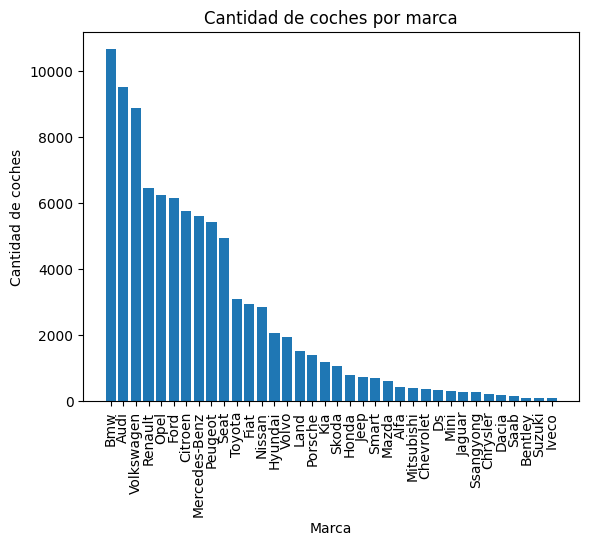

In [72]:
df_clean_make = df_clean['make']
plt.bar(df_clean_make.value_counts().index, df_clean_make.value_counts().values)
plt.xticks(rotation=90)
plt.title('Cantidad de coches por marca')
plt.xlabel('Marca')
plt.ylabel('Cantidad de coches')
plt.show()

In [73]:
df_make_price = df_clean.groupby('make').agg({'price': 'mean'}).reset_index().sort_values('price', ascending=False)

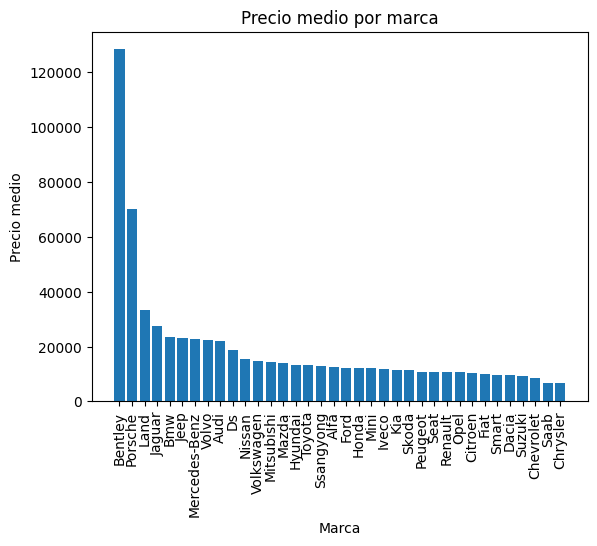

In [74]:
plt.bar(df_make_price['make'], df_make_price['price'])
plt.xticks(rotation=90)
plt.title('Precio medio por marca')
plt.xlabel('Marca')
plt.ylabel('Precio medio')
plt.show()

La marca con precio medio más alto con diferencia es Bentley, seguida de Porsche

In [75]:
df_groupby_model = df_clean.groupby(['model', 'make']).agg({
    'kms': 'mean', 
    'power': 'mean', 
    'months_old': 'mean', 
    'price': 'mean'
}).reset_index()

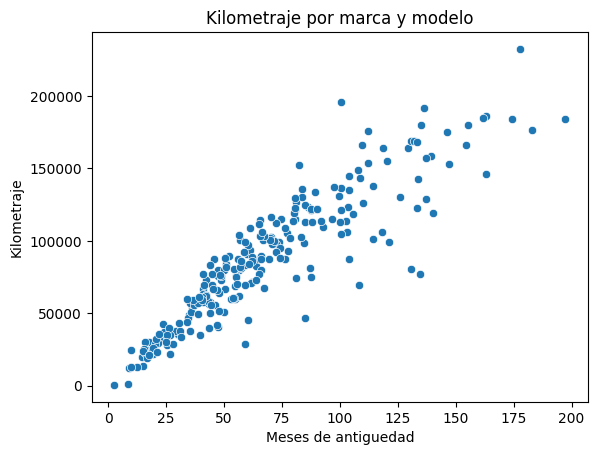

In [76]:
sns.scatterplot(data=df_groupby_model, x='months_old', y='kms')
plt.title('Kilometraje por marca y modelo')
plt.xlabel('Meses de antiguedad')
plt.ylabel('Kilometraje')
plt.show()

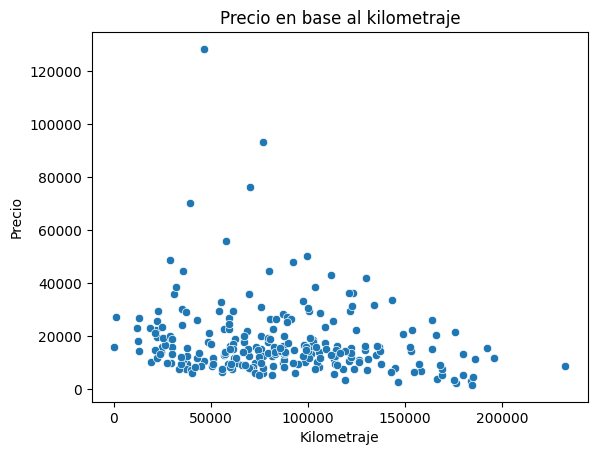

In [77]:
sns.scatterplot(data=df_groupby_model, x='kms', y='price')
plt.title('Precio en base al kilometraje')
plt.xlabel('Kilometraje')
plt.ylabel('Precio')
plt.show()

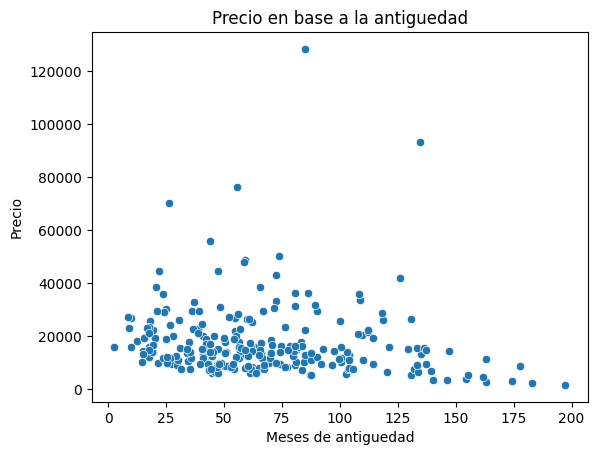

In [78]:
sns.scatterplot(data=df_groupby_model, x='months_old', y='price')
plt.title('Precio en base a la antiguedad')
plt.xlabel('Meses de antiguedad')
plt.ylabel('Precio')
plt.show()

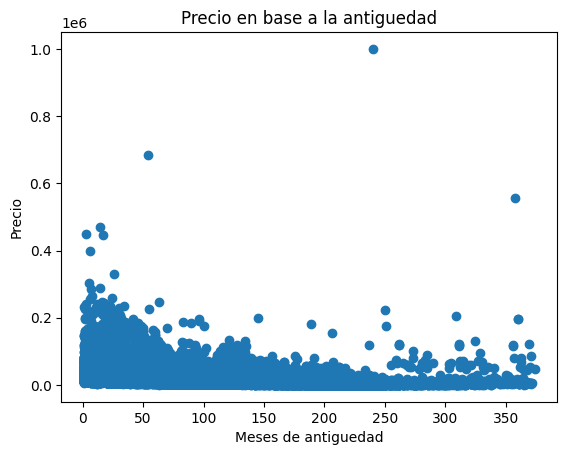

In [79]:
plt.scatter(x=df_clean['months_old'], y=df_clean['price'])
plt.title('Precio en base a la antiguedad')
plt.xlabel('Meses de antiguedad')
plt.ylabel('Precio')
plt.show()

In [80]:
print(df_clean[df_clean['kms'] > 200000]['kms'].count())
total_outliers = len(df_clean[df_clean['kms'] > 200000])
porcentaje = (total_outliers / len(df_clean)) * 100
print(f"Porcentaje de outliers en kms: {porcentaje}")
print(df_clean[df_clean['price'] > 50000]['price'].count())
total_outliers = len(df_clean[df_clean['price'] > 50000])
porcentaje = (total_outliers / len(df_clean)) * 100
print(f"Porcentaje de outliers en price: {porcentaje}")

7149
Porcentaje de outliers en kms: 7.606047387515826
2377
Porcentaje de outliers en price: 2.5289655392537584


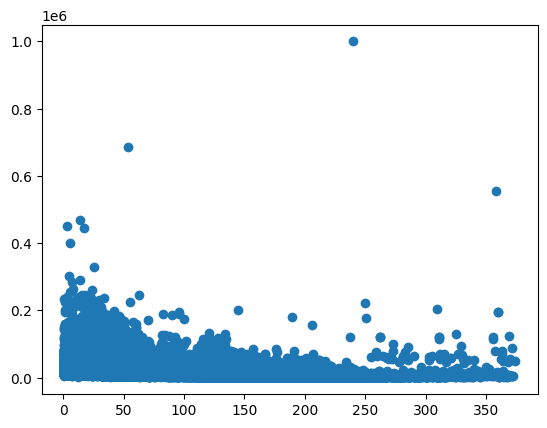

In [81]:
plt.scatter(x= df_clean['months_old'], y=df_clean['price'])

In [82]:
# Eliminamos outliers debido a que generan mayor error en el modelo
df_outlier_clean = df_clean[(df_clean['price'] < 50000) & (df_clean['kms'] < 200000)]

In [83]:
df_outlier_clean

,make,model,version,months_old,power,sale_type,gear_type,fuel_type,kms,price
2385,Porsche,Macan,S Diesel Aut.,45.0,190.0,used,automatic,diesel,119000.0,49999
2386,Bentley,Continental,Gt Coupe 560 Cv,164.0,411.0,used,automatic,gasoline,98000.0,49999
2387,Bentley,Continental,Gt,154.0,412.0,used,automatic,gasoline,95000.0,49999
2388,Bmw,X5,Xdrive40D Automatico Paquete M Completo,45.0,230.0,used,automatic,diesel,90000.0,49999
2389,Audi,A7,Competition 3.0 Tdi Quattro S-Line 326 Cv Biturbo,35.0,240.0,used,automatic,diesel,49715.0,49999
...,...,...,...,...,...,...,...,...,...,...
93984,Volkswagen,Golf,1.6 Match,257.0,74.0,used,manual,gasoline,169500.0,400
93986,Opel,Astra,F Cabrio 1.6I Bertone,275.0,52.0,used,manual,gasoline,134700.0,350
93987,Volkswagen,Polo,1.0 Basic 50,232.0,37.0,used,manual,gasoline,67762.0,350
93989,Seat,Toledo,1.8 Glx A.A.,276.0,66.0,used,manual,gasoline,196000.0,300


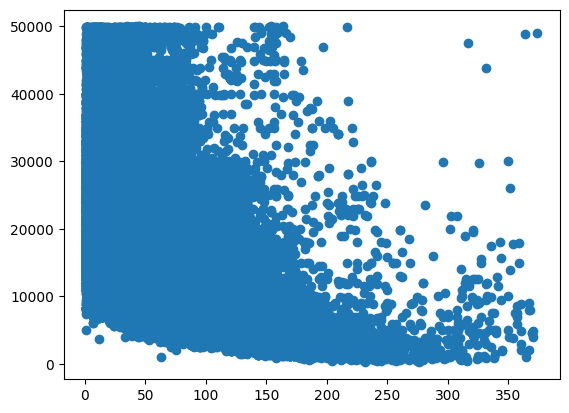

In [84]:
plt.scatter(x= df_outlier_clean['months_old'], y=df_outlier_clean['price'])

In [85]:
# Transformamos las columnas categoricas
df_outlier_clean['model_unique'] = df_outlier_clean['make'] + "_" + df_outlier_clean['model']
df_outlier_clean['version_unique'] = df_outlier_clean['model_unique'] + "_" + df_outlier_clean['version']

# Usamos LabelEncoder porque hay muchos valores unicos y generaría una matriz muy grande, no usamos OrdinalEncoder porque no queremos sesgar el modelo
le = LabelEncoder()
df_outlier_clean['make_num'] = le.fit_transform(df_outlier_clean['make'])
df_outlier_clean['model_num'] = le.fit_transform(df_outlier_clean['model_unique'])
df_outlier_clean['version_num'] = le.fit_transform(df_outlier_clean['version_unique'])

# Para las columnas con menos opciones usamos OneHotEncoder
oe = OneHotEncoder()
cols_to_encode = ['gear_type', 'sale_type', 'fuel_type']

encoded_array = oe.fit_transform(df_outlier_clean[cols_to_encode]).toarray() 

df_encoded = pd.DataFrame(
    encoded_array, 
    columns=oe.get_feature_names_out(cols_to_encode),
    index=df_outlier_clean.index
)

df_final = pd.concat([df_outlier_clean, df_encoded], axis=1)

cols_to_drop = [
    'make', 'model', 'version', 'fuel_type', 'gear_type', 'sale_type', 
    'model_unique', 'version_unique'
]

df_final = df_final.drop(columns=cols_to_drop)

In [86]:
df_final.head()

,months_old,power,kms,price,make_num,model_num,version_num,gear_type_Unknown,gear_type_automatic,gear_type_manual,...,sale_type_new,sale_type_used,fuel_type_CNG,fuel_type_LPG,fuel_type_Unknown,fuel_type_diesel,fuel_type_electric,fuel_type_etanol,fuel_type_gasoline,fuel_type_hybrid
2385,45.0,190.0,119000.0,49999,25,182,25492,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2386,164.0,411.0,98000.0,49999,2,15,3727,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2387,154.0,412.0,95000.0,49999,2,15,3722,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2388,45.0,230.0,90000.0,49999,3,35,6435,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2389,35.0,240.0,49715.0,49999,1,8,2935,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


Vemos que el scatterplot ahora tiene menos outliers por lo que se ve mas completo

In [87]:
X = df_final.drop(columns='price')
y = df_final['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [88]:
model = RandomForestRegressor(n_estimators=125, max_depth=20, random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",125
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [89]:
predict = model.predict(X_test)

mae = mean_absolute_error(y_test, predict)
r2 = r2_score(y_test, predict)
error_relativo = (mae / df_final['price'].mean()) * 100

print(f"MAE: {mae}")
print(f"R2: {r2}")
print(f"Error relativo: {error_relativo}")

MAE: 1359.7112434794362
R2: 0.9385035484430695
Error relativo: 8.661219350944227


In [90]:
model = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [91]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=skf,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


c:\Javi\Proyectos\IberiaDriveInsghts\venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.-

In [92]:
print(f"Mejores hiperparámetros: {grid_search.best_params_}")
print(f"Mejor score (MAE): {-grid_search.best_score_:.2f}")

# El modelo ya está ajustado con los mejores parámetros automáticamente
best_model = grid_search.best_estimator_

Mejores hiperparámetros: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mejor score (MAE): 1387.89


In [97]:
y_pred_final = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_final)
r2 = r2_score(y_test, y_pred_final)
error_relativo = (mae / df_final['price'].mean()) * 100

print(f"MAE: {mae}")
print(f"R2: {r2}")
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_final))}')
print(f"Error relativo: {error_relativo}")

MAE: 1331.5982910192272
R2: 0.9389430560337537
RMSE: 2229.3766411288025
Error relativo: 8.4821427646262


In [94]:
if not os.path.exists('../ai_models'):
    os.makedirs('../ai_models/kaggle')

if not os.path.exists('../ai_models/kaggle'):
    os.makedirs('../ai_models/kaggle')
    
joblib.dump(model, '../ai_models/kaggle/modelo_precio_coches_1.pkl')

# Importante guardar los encoders parea que se puedan conseguir los nombres de las columnas
joblib.dump(le, '../ai_models/kaggle/label_encoder.pkl')
joblib.dump(oe, '../ai_models//kaggle/onehot_encoder.pkl')

['../ai_models//kaggle/onehot_encoder.pkl']

In [95]:
# Exportar dataset limpio
df_to_db = df_clean[(df_clean['price'] < 50000) & (df_clean['kms'] < 200000)]
df_to_db['is_prediction'] = False
df_to_db['rep_id'] = 1

df_to_db.to_csv('../datasets/data_clean.csv', index=False)